#   ZOMATO PROJECT

## Importing libraries

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 



## Reading csv file 

In [39]:
df = pd.read_csv('Zomato data .csv' ,encoding= 'latin-1')

In [40]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


## checking for duplicates 

In [42]:
df.duplicated().sum()

np.int64(0)

## converting rate to float form , and removing '/5'

In [43]:
df['rate']= df['rate'].str.replace('/5' , '' , regex='False') 
df.head()


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [44]:
df['rate']= df['rate'].astype(float)

In [45]:
df['rate'].dtypes

dtype('float64')

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


# (1)  What type of restaurant do the majority of customers order from ?

In [47]:
type_of_resturants = df.groupby('listed_in(type)')['name'].count().reset_index()

type_of_resturants

,listed_in(type),name
0,Buffet,7
1,Cafes,23
2,Dining,110
3,other,8


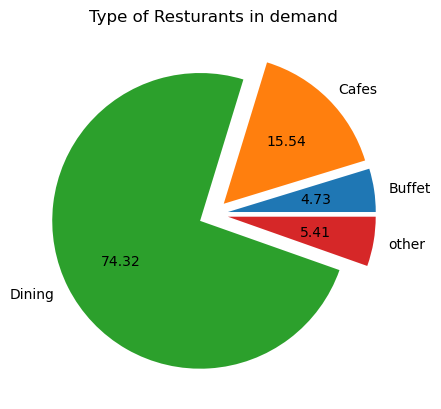

In [48]:
plt.pie(type_of_resturants['name'], labels= type_of_resturants['listed_in(type)'], autopct='%1.2f',
         explode=(.1,.1,.1,.1), 
        )
plt.title('Type of Resturants in demand')

plt.show()

# (2) How many votes has each type of restaurant received from customers ?


In [49]:
Votes_by_Customers= df.groupby('listed_in(type)')['votes'].sum().reset_index()
Votes_by_Customers

,listed_in(type),votes
0,Buffet,3028
1,Cafes,6434
2,Dining,20363
3,other,9367


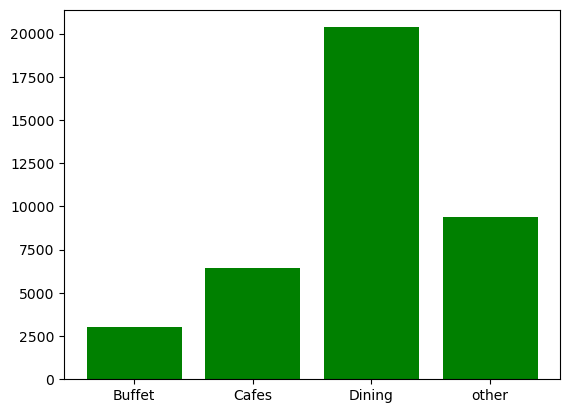

In [50]:
plt.bar( Votes_by_Customers['listed_in(type)'], Votes_by_Customers['votes'], 
        color= 'green' )
plt.show()

# (3) What are the ratings that the majority of restaurants have received ?

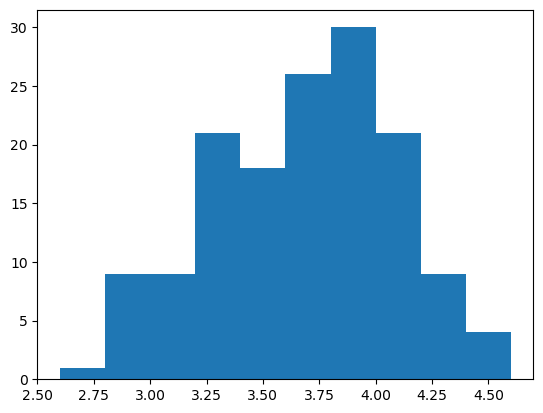

In [51]:
plt.hist(df['rate'])
plt.show()

In [52]:
def Ratings_distribution(df, col ):
    edges= [2.5,3,3.5,4,4.5,5]
    df[col]= pd.cut(df[col]  , duplicates='drop',bins=5)
    return df 

Ratings_distribution(df, 'rate')
df['rate'].unique()

[(3.8, 4.2], (3.4, 3.8], (4.2, 4.6], (3.0, 3.4], (2.598, 3.0]]
Categories (5, interval[float64, right]): [(2.598, 3.0] < (3.0, 3.4] < (3.4, 3.8] < (3.8, 4.2] < (4.2, 4.6]]

In [53]:
Majority_ratings= df.groupby('rate')['name'].count().reset_index()

Majority_ratings

C:\Users\yasha\AppData\Local\Temp\ipykernel_25840\4212272483.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Majority_ratings= df.groupby('rate')['name'].count().reset_index()


,rate,name
0,"(2.598, 3.0]",12
1,"(3.0, 3.4]",40
2,"(3.4, 3.8]",52
3,"(3.8, 4.2]",31
4,"(4.2, 4.6]",13


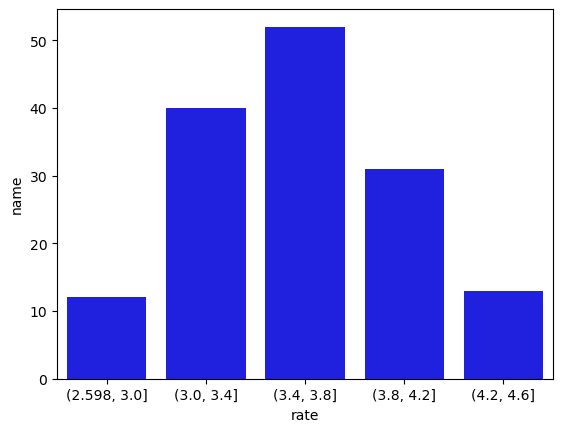

In [54]:
sns.barplot(data= Majority_ratings , x = 'rate' , y= 'name', color= 'blue' )
plt.show()

## (4) Zomato has observed that most couples order most of their food online. What is their average spending on each order?


In [55]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,"(3.8, 4.2]",775,800,Buffet
1,Spice Elephant,Yes,No,"(3.8, 4.2]",787,800,Buffet
2,San Churro Cafe,Yes,No,"(3.4, 3.8]",918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,"(3.4, 3.8]",88,300,Buffet
4,Grand Village,No,No,"(3.4, 3.8]",166,600,Buffet


In [56]:
online = df.groupby('online_order')['approx_cost(for two people)'].mean().round(2).sort_values(ascending = False).reset_index()
online

,online_order,approx_cost(for two people)
0,Yes,510.34
1,No,358.89


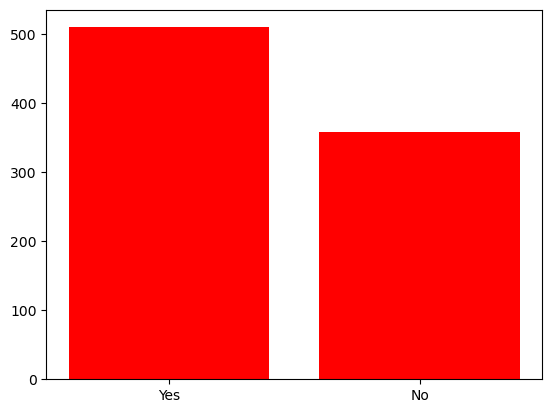

In [57]:
plt.bar(online['online_order'], online['approx_cost(for two people)'], color = 'red')
plt.show()

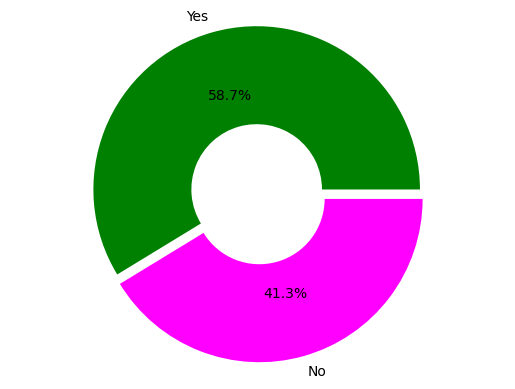

In [89]:
plt.pie(online['approx_cost(for two people)'] , labels= online['online_order'] , autopct= '%1.1f%%', 
         colors = ['green' , 'magenta'],
        wedgeprops= dict(width =.6),
        explode= [.03, .03]
          )
plt.axis('equal')
plt.show()

## (5) Which type of restaurant received more offline orders, so that Zomato can provide those customers with some good offers?

In [59]:
orders = df.groupby('listed_in(type)')['online_order'].value_counts().reset_index()
orders

,listed_in(type),online_order,count
0,Buffet,Yes,4
1,Buffet,No,3
2,Cafes,Yes,15
3,Cafes,No,8
4,Dining,No,77
5,Dining,Yes,33
6,other,Yes,6
7,other,No,2


In [60]:
offline = orders[orders['online_order']== 'No']
offline

,listed_in(type),online_order,count
1,Buffet,No,3
3,Cafes,No,8
4,Dining,No,77
7,other,No,2


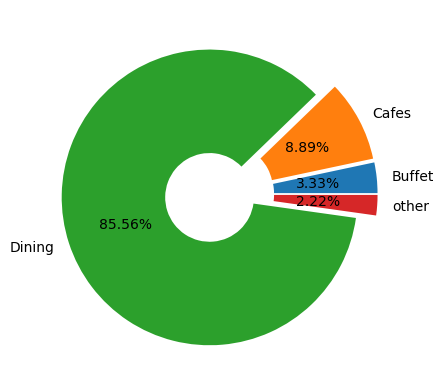

In [87]:
plt.pie(offline['count'],
        labels = offline['listed_in(type)'],
        explode=[.07,.07,.07,.07],
        autopct = '%1.2f%%',
        wedgeprops= dict(width = 0.7))

plt.show()

# SUMMARY

##  1) What type of restaurant do the majority of customers order from?

### Ans : Dining

##   2) How many votes has each type of restaurant received from customers?
### Ans : Dining
##    3) What are the ratings that the majority of restaurants have received?
### Ans : (3.4, 3.8]
##    4)Zomato has observed that most couples order most of their food online. What is the average spending on each order?
### Ans : 510.34
##    5) Which type of restaurant received more offline orders, so that Zomato can provide those customers with some good offers
### Ans : Dining